# Small Hamming Weight Denominations for CoinJoins

Standardizing on a small set of denominations has advantages, among other use cases, for privacy in CoinJoin transactions. Given an arbitrary amount, if instead of creating a single output this amount is approximated from below by a sum of standard denominations each such output will be less linkable to the input cluster which funded it.

The fewer denominations there are to choose from, the more likely it is that any one denomination will be chosen by more than one user, which improves privacy. But this comes at a cost of requiring more outputs to represent a given balance.

Too few denominations, and the approximations become too crude and lossy. This notebook examines the gap sizes of the sums of combinations up to size $k$ of elements from a set of values with Hamming weight 1. In order to approximate values ranging up to $n$ sats, the size of the set of denominations smaller than $n$ scales as $O(\log n )$.

## Sub-transaction model and implications for privacy

In the sub-transaction model ([1](https://m.flrn.cc/academic/2017_CoinJoin.pdf), [2](https://medium.com/@laurentmt/introducing-boltzmann-85930984a159)), for every repeated value with multiplicity $k$ in the inputs or the outputs of a sub-transaction mapping as a whole, $k!$ equivalent mappings can be obtained by permution. Clearly this does not change the sum of any sub-transaction, and therefore preserves condition.

Within a sub-transaction in the mapping permutations have no effect on sub-transaction assignment. The product of the factorials of those must be divided out of the equivalent mappings estimate.

In base 2, a value with multiplicity 2 within a single sub-transaction is are exchangeable with the next denomination up from some other sub-transaction. Base 3 and 10 have somewhat more complex arithmetic relationships which imply yet more permutations of subsets of coins.

If an arbitrary output value (i.e. with large Hamming weight) can be constructed -- or more generally than in Maurer et al, approximated -- by summing together $k$ distinct denominations, and each of which has multiplicity $m$ in the outputs of the sub-transaction mapping as a whole, then a number number of equivalent mappings is $k \times m!$. This counts permutations over sets of subsets of outputs, specifically when a subset of size $k$ is exchanged with a subset of size $1$.

Although this preserves the nominal sum of the sub-transaction its effective cost and therefore inferred fee will differ. A high variance in sub-transaction is less likely, so unlike 1:1 exchanges, k:1 exchanges are not perfectly symmetric. Users who attempt to recover every last sat are more susceptible to such analysis.

More generally, sets which generate dense subset sum instances place fewer constraints on sub-transaction mapping enumeration. A dense subset sum instance with non-trivial multiplicities implies that for every input or output, the number of distinct sub-transactions it appears in across all non-derived sub-transaction mappings is large. This is because for any random subset of inputs or outputs it may co-occur with, subset sum is likely still be dense after removing this random subset (due to the non trivial multiplicities).

## Radix CoinJoin

A logarithmic (in the range of values) number of small Hamming weight values with non-trivial multiplicity, taken from a geometric progression can therefore provide cover for any number of arbitrary valued inputs and outputs. Larger Hamming weight values with multiplicity 1, can of course contribute to subset sum density, but a geometric progression with high multiplicity is much more robust and trivial to analyze.

Ignoring any hypothetical UTXO sharing, the anonymity set size of a CoinJoin transaction is constrained by the number of inputs or the number outputs (the smaller of the two). Even if the number estimated number of distinct sub-transactions in which a coin appears is very large, this only means that the sub-transaction mappings will not be the limiting constraint on anonymity set size for this coin. Therefore even loose lower bounds on this value are sufficient in practice.

## Mixed bases and preferred values

If using only a single base, when a small fee cost is subtracted from a single denomination this will result in a remaining balance with a large Hamming weight in that base. To get around this to some extent, values from multiple bases can be used. Additionally, not all Hamming weight 1 values are required, a [preferred value series](https://en.wikipedia.org/wiki/Preferred_number) can approximate values well with a smaller number of denominations.

Currency conversions often results in excessively precise bitcoin amounts. In some base $b$, a value $v$ will have expected weight $\frac{(b-1) \log_b v}{b}$. Values which have a small weight in one base usually have a large weight in another, in particular bases 2 and 3. The result of subtracting a value with weight 1 in base 3 from a value with a large weight in base 2 can often have a weight that is smaller by more than 1 (but it may also be higher).

Concretely, the 1-2-5 series in base 10 is useful for representing values with a decimal bias. Base 2 and 3 are suitable for decomposing arbitrary values with a high decimal Hamming weight. They are also complementary to each other, the 1-2 series in base 3 has a high hamming weight in base 2 and powers of 2 have a high hamming weight in base 3. These additional values also improve the overall density, reducing the sizes of combinations required for good approximations. Beyond this, additional denominations provide diminishing returns.

As we will see in detail, within any practical range, most values can usualy be approximated reasonably well even with only 3 outputs. The vast majority can be closely approximated with 4. Practically all values are addressible with 5, and with combinations of size 6, gaps larger than the dust threshold (for 1 sat/vbyte) vanish entirely.

This python implementation is optimized for simplicity, not performance or memory use, and the nature of this problem lends itself to precomputation. In an optimized implementation it's possible to exhaustively enumerate all possibilities even as part of an online computation. This is worth noting because for privacy choosing uniformly at random between an unbiased selection of acceptable choices is better than always picking the best choice according to the cost function. A black box optimization approach may introduce such a bias depending on the cost function.

# Parameters

The minimal feerate can be controlled in order to vary the dust threshold.

In [ ]:
# @title bitcoin network parameters
max_sats = 2099999997690000
dust_feerate = 3.0
expected_feerate = 10.0
min_vbytes = 98 # 294 sats @ 3 sat/vb for p2wpkh per https://bitcoin.stackexchange.com/a/41082
dust = int(min_vbytes * dust_feerate)

We will generate denominations from the dust threshold to some maximum value. Setting a large `max_denom` smooths the gap distribution and emphasizes the gaps between the larger magnitude values, which tend to have smaller relative differences. `max_combination_value` is set because sumsets are sparse at the upper extremity, since the largest sums involve repetitions of the largest denominations.

In [ ]:
# @title denomination parameters
min_denom = dust
max_denom = int(1e8) # reducing this reveals some interesting structure in the plots below
max_combination_size = 6 # 7 is slow but doable, and consumes lots of ram for larger values of max_denom with this naive implementation. results are not very interesting, median gap size is 1 sat.
max_combination_value = max_denom * 2

The final parameters set a cutoff for the smallest gaps. The smallest possible gap is of size 1. Setting a higher cutoff omits negligible gaps (e.g. below `dust`) improving readability of the individual histograms with regards to larger gaps. Low values aid in comparing between sumset degrees.

In [ ]:
# @title analysis parameters
min_diff = 2 # setting to dust hides small gaps, focusing on more significant ones
min_diff_ratio = 0 # 1e-4 is a basis point

# Generate denominations

In [ ]:
# @title import boilerplate
from math import log, ceil

from itertools import combinations_with_replacement, product

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Denominations are based on [preferred value series](https://en.wikipedia.org/wiki/Preferred_number) in base 2, 3, and 10.

In [ ]:
# @title helper functions
def powers(b: int) -> set[int]:
  """
  Generates powers of the given base within the min/max denomination range
  """
  return { b**i for i in range(int(ceil(log(min_denom)/log(b))), int(log(max_denom)/log(b))+1) }

def multiples(vs: set[int], cs: set[int]) -> set[int]:
  """
  Computes the products of pairs of values from two sets.
  """
  return { c*v for (c,v) in product(cs,vs) if c*v in range(min_denom, max_denom+1) }

In [ ]:
# @title denominations of different bases
binary  = multiples(powers(2),  {1})
ternary = multiples(powers(3),  {1,2})
decimal = multiples(powers(10), {1,2,5})

In [ ]:
# these aditional Hamming weight 2 values plug the proportionally largest gaps
# between the denominations this has some impact on the decomposition of smaller
#  values (max_denom <= 1e6 or so) and so seem appropriate for a future with a
# lower dust feerate, but marginal benefit today

#binary = binary | multiples({3}, { 2**i for i in [ 10, 13, 15, 18 ]})

# the addition of 3 * 2^n arguably over-represents base 2 values
# https://en.wikipedia.org/wiki/Preferred_number#Computer_engineering

#binary  = multiples(powers(2), {1,3})

The combined set of denominations is just a union of these Hamming weight 1 values in these 3 useful bases.

In [ ]:
# @title combined denomination set
combined = binary | ternary | decimal

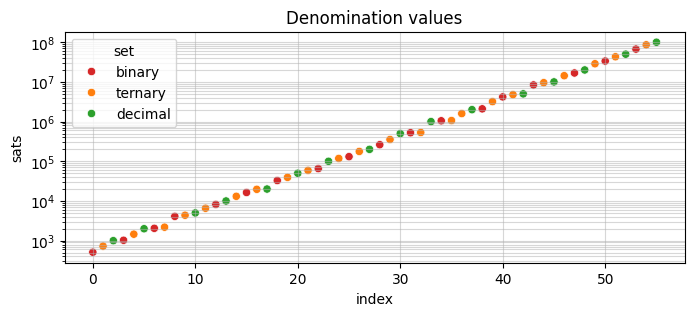

In [ ]:
# @title denomination values
palette = {'binary': 'tab:red', 'ternary': 'tab:orange', 'decimal': 'tab:green', 'combined': 'tab:blue'}
origin = { v: 'binary' for v in binary } | { v: 'ternary' for v in ternary } | { v: 'decimal' for v in decimal }

combined_index = {value: index for index, value in enumerate(sorted(combined))}

plt.figure(figsize=(8,3))
sns.scatterplot(data=pd.DataFrame([{'value': v, 'index': combined_index[v], 'set': origin[v]} for v in sorted(combined) ]), x='index', y='value', hue='set', palette=palette)

plt.yscale('log')
plt.ylabel('sats')
plt.title('Denomination values')
plt.grid(True, which='both', alpha=0.5)
plt.show()

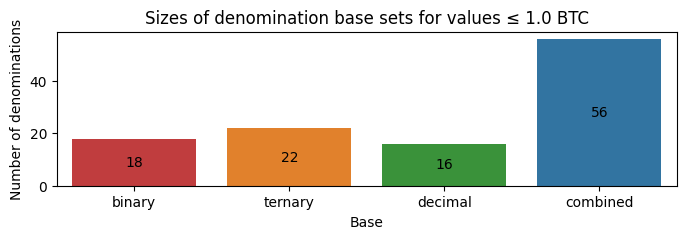

In [ ]:
# @title denomination set sizes
data = {
    'set': ['binary', 'ternary', 'decimal', 'combined'],
    'size': [len(binary), len(ternary), len(decimal), len(combined)],
    'color': [palette['binary'], palette['ternary'], palette['decimal'], palette['combined']]
}
df_sets = pd.DataFrame(data)

plt.figure(figsize=(8, 2))
ax = sns.barplot(x='set', y='size', hue='set', data=df_sets, palette=palette, legend=False)
plt.xlabel('Base')
plt.ylabel('Number of denominations')
plt.title(f'Sizes of denomination base sets for values ≤ {max_denom/1e8} BTC')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='center')

plt.show()

In [ ]:
# @title denominations table
from google.colab import data_table
data_table.enable_dataframe_formatter()

def hamming_weight(n, base):
    """Calculates the Hamming weight of n in a given base."""
    if n == 0:
        return 0
    weight = 0
    while n > 0:
        weight += n % base != 0
        n //= base
    return weight

pd.DataFrame([{
      'set': origin[x],
      'value': "{0:.8f}".format(x/1e8),
      'binary (little endian)': "{0:b}".format(x)[::-1],
      'popcount': bin(x).count('1'),
      'weight (base 3)': hamming_weight(x, 3),
      'weight (base 10)': hamming_weight(x, 10)
  } for x in sorted(combined) ])

,set,value,binary (little endian),popcount,weight (base 3),weight (base 10)
0,binary,0.00000512,0000000001,1,4,3
1,ternary,0.00000729,1001101101,6,1,3
2,decimal,0.00001000,0001011111,6,4,1
3,binary,0.00001024,00000000001,1,6,3
4,ternary,0.00001458,01001101101,6,1,4
5,decimal,0.00002000,00001011111,6,4,1
6,binary,0.00002048,000000000001,1,6,3
7,ternary,0.00002187,110100010001,5,1,4
8,binary,0.00004096,0000000000001,1,7,3
9,ternary,0.00004374,0110100010001,5,1,4


# Generate sumsets

`{0}` is unioned with the denominations in order to obtain the sumsets from combinations of size $\leq k$ as opposed to $=k$.

In [ ]:
# @title compute sumsets naively

sumsets = []
for k in range(1, max_combination_size+1):
  subsets = combinations_with_replacement({0} | combined, k)
  sumset = { s for s in map(sum, subsets) if s in range(1,max_combination_value+1) }
  sumsets.append(np.array(sorted(sumset)))

In [ ]:
# @title (fail to) compute sumsets more efficiently
import numpy as np
from numpy.fft import fft, ifft
from math import log2

def sumset_k_fft(nums, k):
  """
  Compute sumset via FFT, same as above but supposedly faster
  """
  nums = np.array(sorted(nums))
  max_sum = np.max(nums) * k
  poly = np.zeros(2**ceil(log2(max_sum)))
  poly[nums] = 1
  F = fft(poly)
  Fk = F ** k
  result = np.rint(ifft(Fk).real).astype(int)
  sums = np.where(result > 0)[0]
  sums = sums[(sums >= min_denom) & (sums <= max_combination_value)]
  return sums

# this is actually slower, so don't do it
#sumsets = [sumset_k_fft({0} | combined, k) for k in range(1, max_combination_size+1)]

In [ ]:
# @title compute gaps naively
# gaps = [np.array([ d for d in (b - a for a,b in zip(s, s[1:])) if min_diff <= d ]) for s in sumsets]

In [ ]:
# @title compute gaps efficiently
gaps = []
for s in sumsets:
  diffs = np.diff(s)
  gaps.append(diffs[diffs >= min_diff])

For the relative gap size, omit gaps below the dust threshold. These gaps are neglibible and unrecoverable (since an additional outputs has a cost), and are therefore noise. To to improve clarity of the plots they are filtered out of the relative differences.

In [ ]:
# @title compute normalized gaps naively
#relative_gaps = [np.array([ p for d, p in ((b-a, (b-a)/b) for a,b in zip(s, s[1:])) if dust <= d and min_diff_ratio <= p ]) for s in sumsets]

In [ ]:
# @title compute normalized gaps efficiently

relative_gaps = []
for s in sumsets:
    diffs = np.diff(s)
    relative_diffs = diffs / s[1:]
    mask = (diffs >= dust) & (relative_diffs >= min_diff_ratio)
    relative_gaps.append(relative_diffs[mask])

# Plots

In [ ]:
# @title dataframe boilerplate

all_gaps_data = np.concatenate(gaps)
all_gaps_k_values = np.concatenate([np.full(len(g_arr), i + 1) for i, g_arr in enumerate(gaps)])
df_gaps = pd.DataFrame({'d': all_gaps_data, 'k': all_gaps_k_values})

all_rel_gaps_data = np.concatenate(relative_gaps)
all_rel_gaps_k_values = np.concatenate([np.full(len(rg_arr), i + 1) for i, rg_arr in enumerate(relative_gaps)])
df_rel_gaps = pd.DataFrame({'r': all_rel_gaps_data, 'k': all_rel_gaps_k_values})

## Gaps

### Count and sizes

Here we compare the gaps (ignoring gaps of size 1) of the sumsets of different degrees. As larger combinations are permitted the number of distinct sums grows and with them the number of gaps between these sums. Because these values are all in a fixed range, the sizes of the more numerous gaps of sumsets of higher degrees are of course smaller.

Note that for $k \in \{1, 6\}$ the scatterplots are a little misleading. For $k=1$ there aren't that many distinct values, so even though these values are smoothly distributed the quantile values aren't. For $k=6$ several quantiles are all entirely gaps of size 1, then several for 2 and 3, the spacings these in the scatter plot are a visual artifact arising from plotting integer values.

<Figure size 800x400 with 0 Axes>

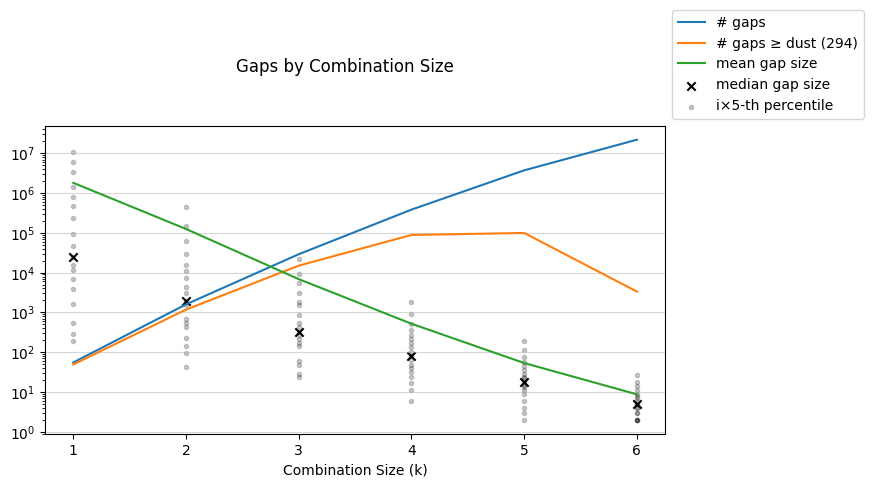

In [ ]:
# @title
gap_sizes = list(map(len, gaps))
gap_sizes_larger_than_dust = list(map(lambda x: max(len(x),1), [ [x for x in s if dust <= x] for s in gaps ]))
ks = list(range(1, max_combination_size + 1))

plt.figure(figsize=(8, 4))
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.set_xlabel('Combination Size (k)')
ax1.tick_params(axis='y')
ax1.set_xticks(ks)
ax1.grid(axis='y', alpha=0.5)
ax1.set_yscale("log")

ax1.plot(ks, gap_sizes, label="# gaps")
ax1.plot(ks, gap_sizes_larger_than_dust, label=f"# gaps ≥ dust ({dust})")

mean_gap_sizes = df_gaps.groupby('k')['d'].mean()
median_gap_sizes = df_gaps.groupby('k')['d'].median()
quantiles = df_gaps.groupby('k')['d'].quantile([i/20 for i in range(1, 20)])

ax1.plot(ks, mean_gap_sizes.values, label='mean gap size')

ax1.scatter(ks, median_gap_sizes.values, color='black', marker='x', label='median gap size')

for i in range(1, 20):
    if i == 5: # skip median
      continue
    quantile_values = quantiles.loc[(slice(None), i/20)].values
    ax1.scatter(ks, quantile_values, marker='.', color='black', alpha=0.2, label=f'i×5-th percentile' if i == 1 else None)

fig.suptitle('Gaps by Combination Size', y=1.05)
fig.legend(loc="lower left", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

plt.show()

#### Gap sizes distribution

The next two plots show the gaps in more detail, both their sizes and their sizes in relation to the next larger value. When decomposing into low Hamming weight values, the total balance being decomposed may fall in one of these gaps. The distribution of their sizes bounds the loss from the decomposition. Here too small integer values create visual artifacts, the empty bins for $k>3 are empty because the populated bins interspersing them correspond to successive integer values.

In [ ]:
bins = 300

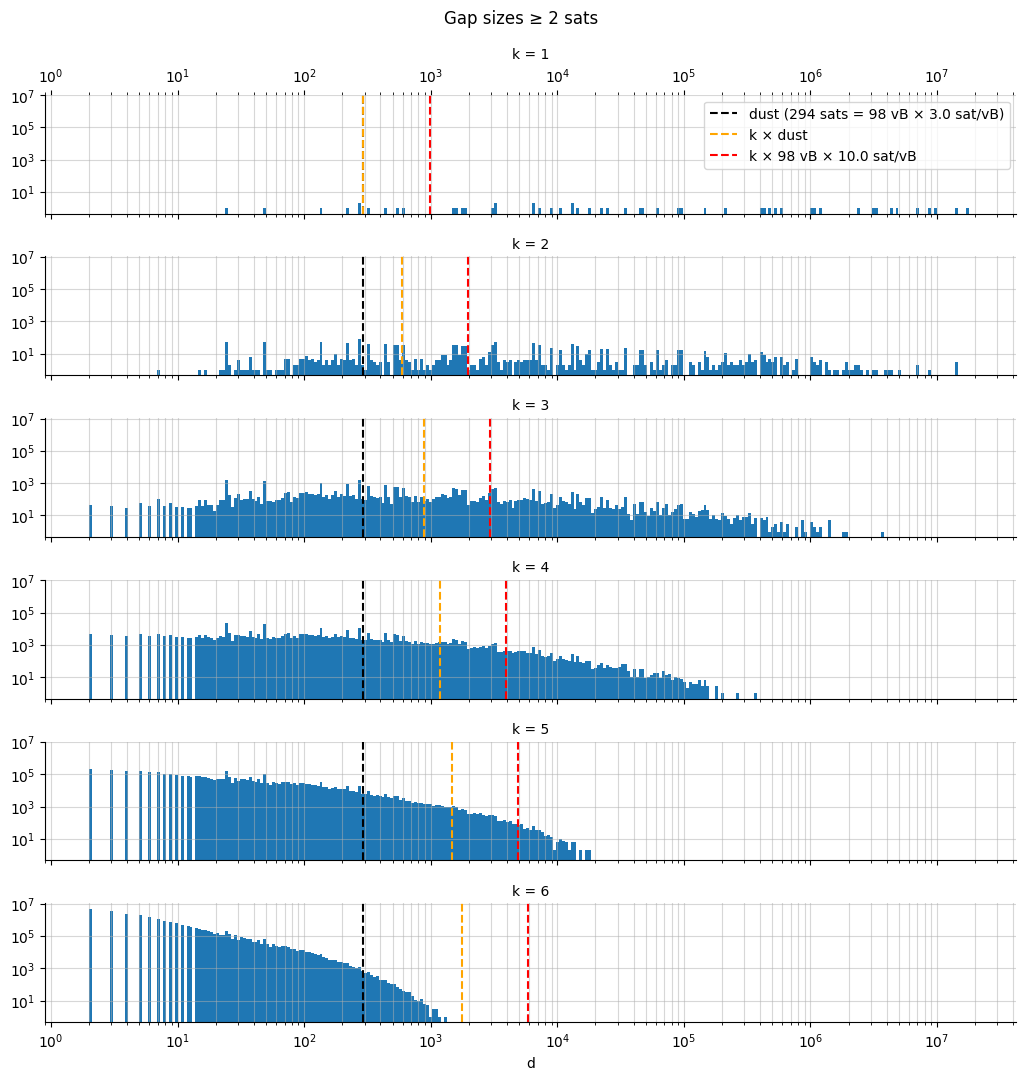

In [ ]:
# @title
min_gap = df_gaps['d'].min()
gap_bins = np.logspace(np.log10(min_gap), np.log10(df_gaps['d'].max()), bins)
g_abs_hist_binned = sns.FacetGrid(df_gaps, col='k', col_wrap=1, height=1.7, aspect=6)
g_abs_hist_binned.map(plt.hist, 'd', bins=gap_bins)
g_abs_hist_binned.set(xscale="log", yscale="log")
g_abs_hist_binned.fig.suptitle(f'Gap sizes ≥ {min_gap} sats', y=1.05)
for i, ax in enumerate(g_abs_hist_binned.axes.flat):
  k = i+1
  ax.grid(True, which='both', alpha=0.5)
  if min_diff < dust:
    ax.axvline(x=dust, color='black', linestyle='--', label=f'dust ({dust} sats = {min_vbytes} vB × {dust_feerate} sat/vB)')
  ax.axvline(x=k*dust, color='orange', linestyle='--', label='k × dust')
  ax.axvline(x=k*(expected_feerate * min_vbytes), color='red', linestyle='--', label=f'k × {min_vbytes} vB × {expected_feerate} sat/vB')
  if i == 0:
    ax.legend()
    ax.secondary_xaxis('top').spines['top'].set_visible(False)
plt.show()

#### Relative gap size

The next plot displays gaps larger than the dust threshold as a fraction of the larger value. No quantization artifacts arise in this plot, but there is a cutoff imposed by dividing by values no larger than the maximum combination value.

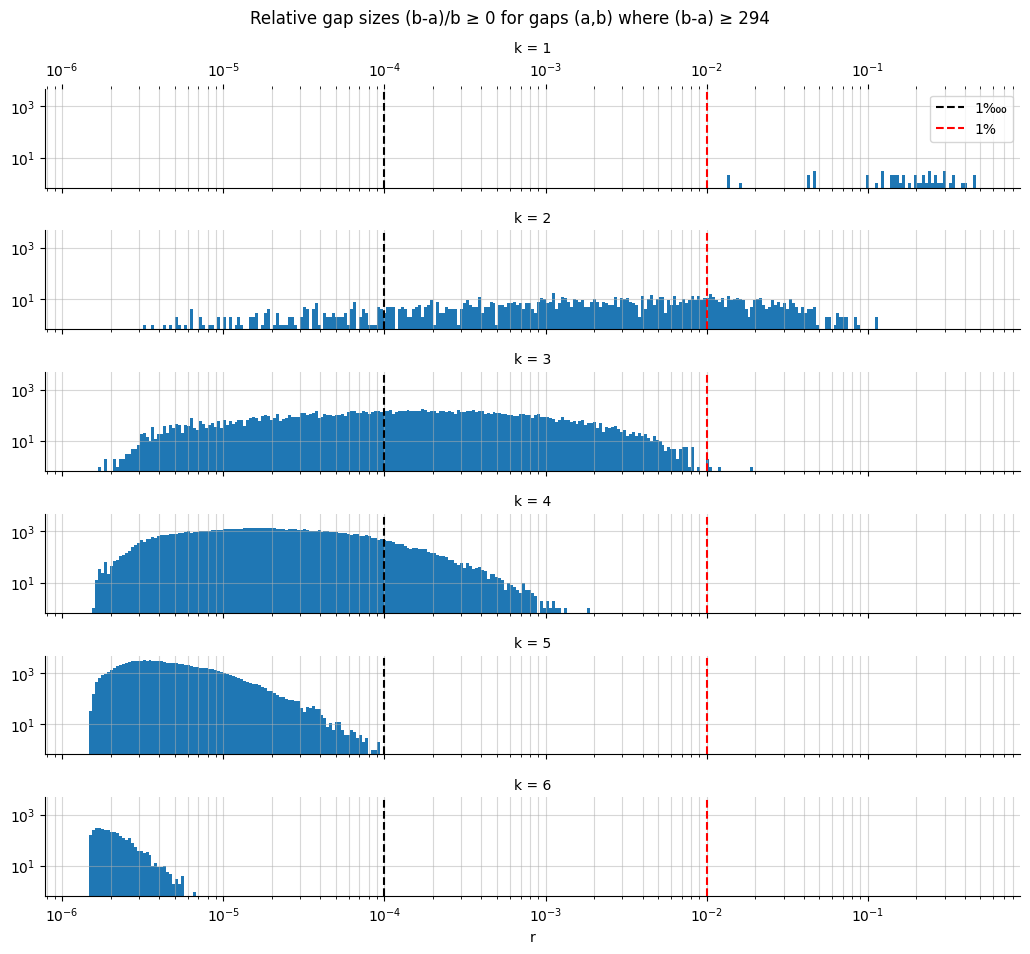

In [ ]:
# @title
ratio_bins = np.logspace(np.log10(df_rel_gaps['r'].min()), np.log10(df_rel_gaps['r'].max()), bins)
g_ratio_hist_binned = sns.FacetGrid(df_rel_gaps, col='k', col_wrap=1, height=1.5, aspect=7)
g_ratio_hist_binned.map(plt.hist, 'r', bins=ratio_bins)
g_ratio_hist_binned.set(xscale="log", yscale="log")
g_ratio_hist_binned.fig.suptitle(f'Relative gap sizes (b-a)/b ≥ {min_diff_ratio} for gaps (a,b) where (b-a) ≥ {dust}', y=1.05)
for i, ax in enumerate(g_ratio_hist_binned.axes.flat):
  ax.grid(True, which='both', alpha=0.5)
  ax.axvline(x=1e-4, color='black', linestyle='--', label='1‱')
  ax.axvline(x=1e-2, color='red', linestyle='--', label='1%')
  if i == 0:
    ax.legend()
    ax.secondary_xaxis('top').spines['top'].set_visible(False)
plt.show()

## Sums and combinations

### Density of distinct sums

The next plot shows the density of distinct sums in the integers. The previous plots show the gap sizes over the entire range, but not all balances decompose as readily, and towards the end of the range the density tapers off (see `max_combination_value` parameter). The initial ramp up is determined by the size of the smallest denomination (see also `dust_feerate` parameter)

This plot gives a clearer indication of the expected loss as a function of the balance being decomposed into a sum of standard values. The distinct constructible sums are assigned into bins (ranges of natural numbers). To plot each bin, this number of distinct values is divided by the size of the bin (number of distinct values, or difference between smallest and largest values).

A density of 1 implies every possible integer value in the bin can be constructed exactly, and a density $\geq\mathrm{dust}^{-1}$ means every value can be approximated from below with error smaller than the dust threshold.

More intuitively, anything above the dashed line means values can be well approximated often enough that the loss is on average negligible (the cost of an additional output will be higher even at the minimum relay fee). The difference in costs will be linear in $k$, smaller combinations are more efficient representations of a given value but concrete efficiency depends on the feerate, and at higher feerates.

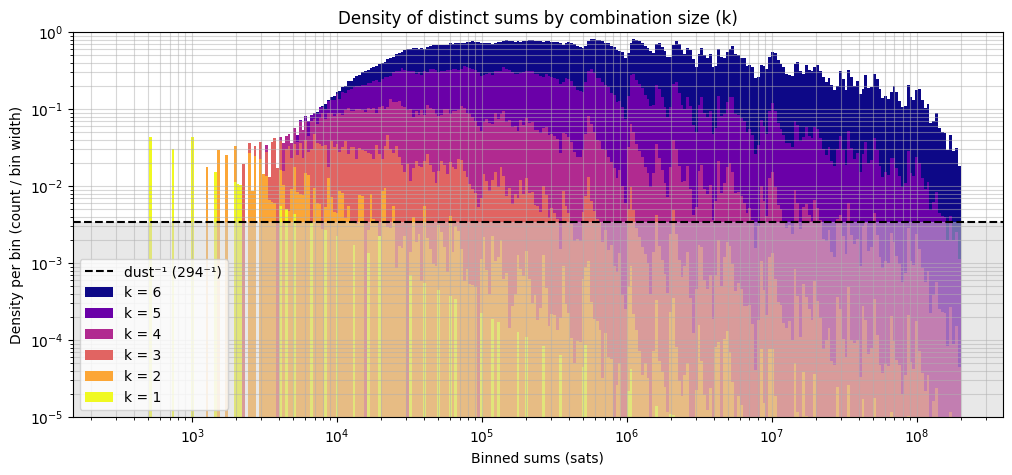

In [ ]:
# @title
min_sum = min_denom
max_sum = max_combination_value

log_bins = np.logspace(np.log10(min_sum), np.log10(max_sum), bins)

plt.figure(figsize=(12, 5))

colors = plt.cm.plasma(np.linspace(0, 1, max_combination_size))[::-1]

# similar to density=True except there's no division by the total entry count,
# which allows comparing the relative densities of different combination sizes
for i in range(max_combination_size -1 , -1, -1):
    k = i + 1
    if len(log_bins) > 1:
        counts, bin_edges = np.histogram(sumsets[i], bins=log_bins)
        bin_widths = np.diff(bin_edges)
        density = counts / bin_widths
        plt.bar(bin_edges[:-1], density, width=bin_widths, color=colors[i], label=f'k = {k}', align='edge')

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 1)
plt.xlabel('Binned sums (sats)')
plt.ylabel('Density per bin (count / bin width)')
plt.title(f'Density of distinct sums by combination size (k)')
plt.axhline(y=1/dust, color='black', linestyle='--', label=f'dust⁻¹ ({dust}⁻¹)')

plt.axhspan(ymin=0, ymax=1/dust, facecolor='lightgrey', alpha=0.5)

plt.legend(loc='lower left')
plt.grid(True, which='both', alpha=0.5)
plt.show()

### Distinct combinations vs. distinct sums

The following plot displays the possible combinations (as opposed to the distinct sums of the previous plot), which gives an indication for how many ways of constructing a possible sum there are as the combination size increases.

<Figure size 800x500 with 0 Axes>

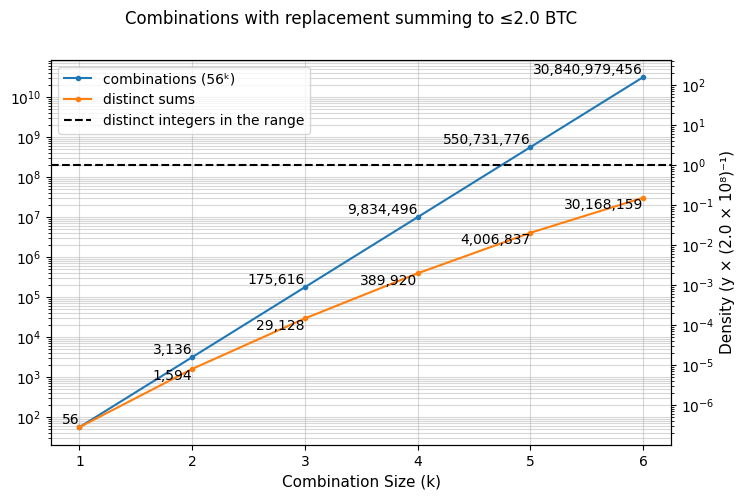

In [ ]:
# @title
plt.figure(figsize=(8, 5))
fig, ax1 = plt.subplots(figsize=(8, 5))

ks = list(range(1, max_combination_size + 1))
num_combinations = [ len(combined)**k for k in range(1, max_combination_size+1) ]
combination_density = [ len(combined)**k / max_combination_value for k in range(1, max_combination_size+1) ]


ax1.set_xlabel('Combination Size (k)', fontsize=11)
ax1.set_yscale("log")
ax1.plot(ks, num_combinations, marker='.', label=f"combinations ({len(combined)}ᵏ)")
ax1.plot(ks, list(map(len, sumsets)), marker='.', label="distinct sums")
plt.axhline(y=max_combination_value, color='black', linestyle='--', label="distinct integers in the range")
ax1.legend()
for i, k in enumerate(ks):
    ax1.text(k, num_combinations[i], f'{num_combinations[i]:,}', ha='right', va='bottom')
    if k > 1:
      ax1.text(k, len(sumsets[i]), f'{len(sumsets[i]):,}', ha='right', va='top')

ax1.grid(True, which='both', alpha=0.5)


fig.suptitle(f'Combinations with replacement summing to ≤{max_combination_value/1e8} BTC')

ax2 = ax1.twinx()
exponent = int(np.floor(np.log10(max_combination_value)))
mantissa = max_combination_value / (10**exponent)
def sup(n):
    """Converts an integer to a unicode superscript string."""
    superscript_map = {
        '0': '⁰', '1': '¹', '2': '²', '3': '³', '4': '⁴', '5': '⁵', '6': '⁶',
        '7': '⁷', '8': '⁸', '9': '⁹', '-': '⁻'
    }
    return ''.join(superscript_map.get(digit, digit) for digit in str(n))
ax2.set_ylabel(f'Density (y × ({mantissa:.1f} × 10{sup(exponent)}){sup(-1)})', fontsize=11)
ax2.set_yscale("log")
ax2.scatter(ks, combination_density, alpha=0)

plt.show()